In [3]:
import os
import pandas as pd

def load_all_leadlag_pairs(metric, k=5):
    decile_pairs = [(i, 11 - i) for i in range(1, 6)]
    all_pairs_data = {}

    for p_idx, c_idx in decile_pairs:
        pair_key = f"d{p_idx}_d{c_idx}"
        df_list = []
        
        for year in range(2014, 2026):
            file_path = f"../../data/08_lead_lag/leadlag_{metric}_{year}_{k}_{pair_key}.csv"
            if os.path.exists(file_path):
                df_temp = pd.read_csv(file_path, index_col=0)
                df_list.append(df_temp)
        
        if df_list:
            all_pairs_data[pair_key] = pd.concat(df_list).sort_index()
            
    return all_pairs_data

hrm_results = load_all_leadlag_pairs("hrm", k=5)
pozzi_results = load_all_leadlag_pairs("pozzi", k=5)

all_metrics_data = {"HCM": hrm_results, "Pozzi": pozzi_results}

# Carregando Market Cap Lead-Lag
df_mcap_list = []
for year in range(2014, 2026):
    file_path = f"../../data/08_lead_lag/marketcap_leadlag_df_{year}.csv"
    if os.path.exists(file_path):
        df_temp = pd.read_csv(file_path, index_col=0)
        # Padroniza a nomenclatura da coluna (ls -> cp) para facilitar o plot no loop
        df_temp = df_temp.rename(columns={"ls1d": "cp1d", "ls1w": "cp1w", "ls2w": "cp2w", "ls1m": "cp1m"})
        df_mcap_list.append(df_temp)

if df_mcap_list:
    mcap_results = pd.concat(df_mcap_list).sort_index()
else:
    mcap_results = pd.DataFrame()


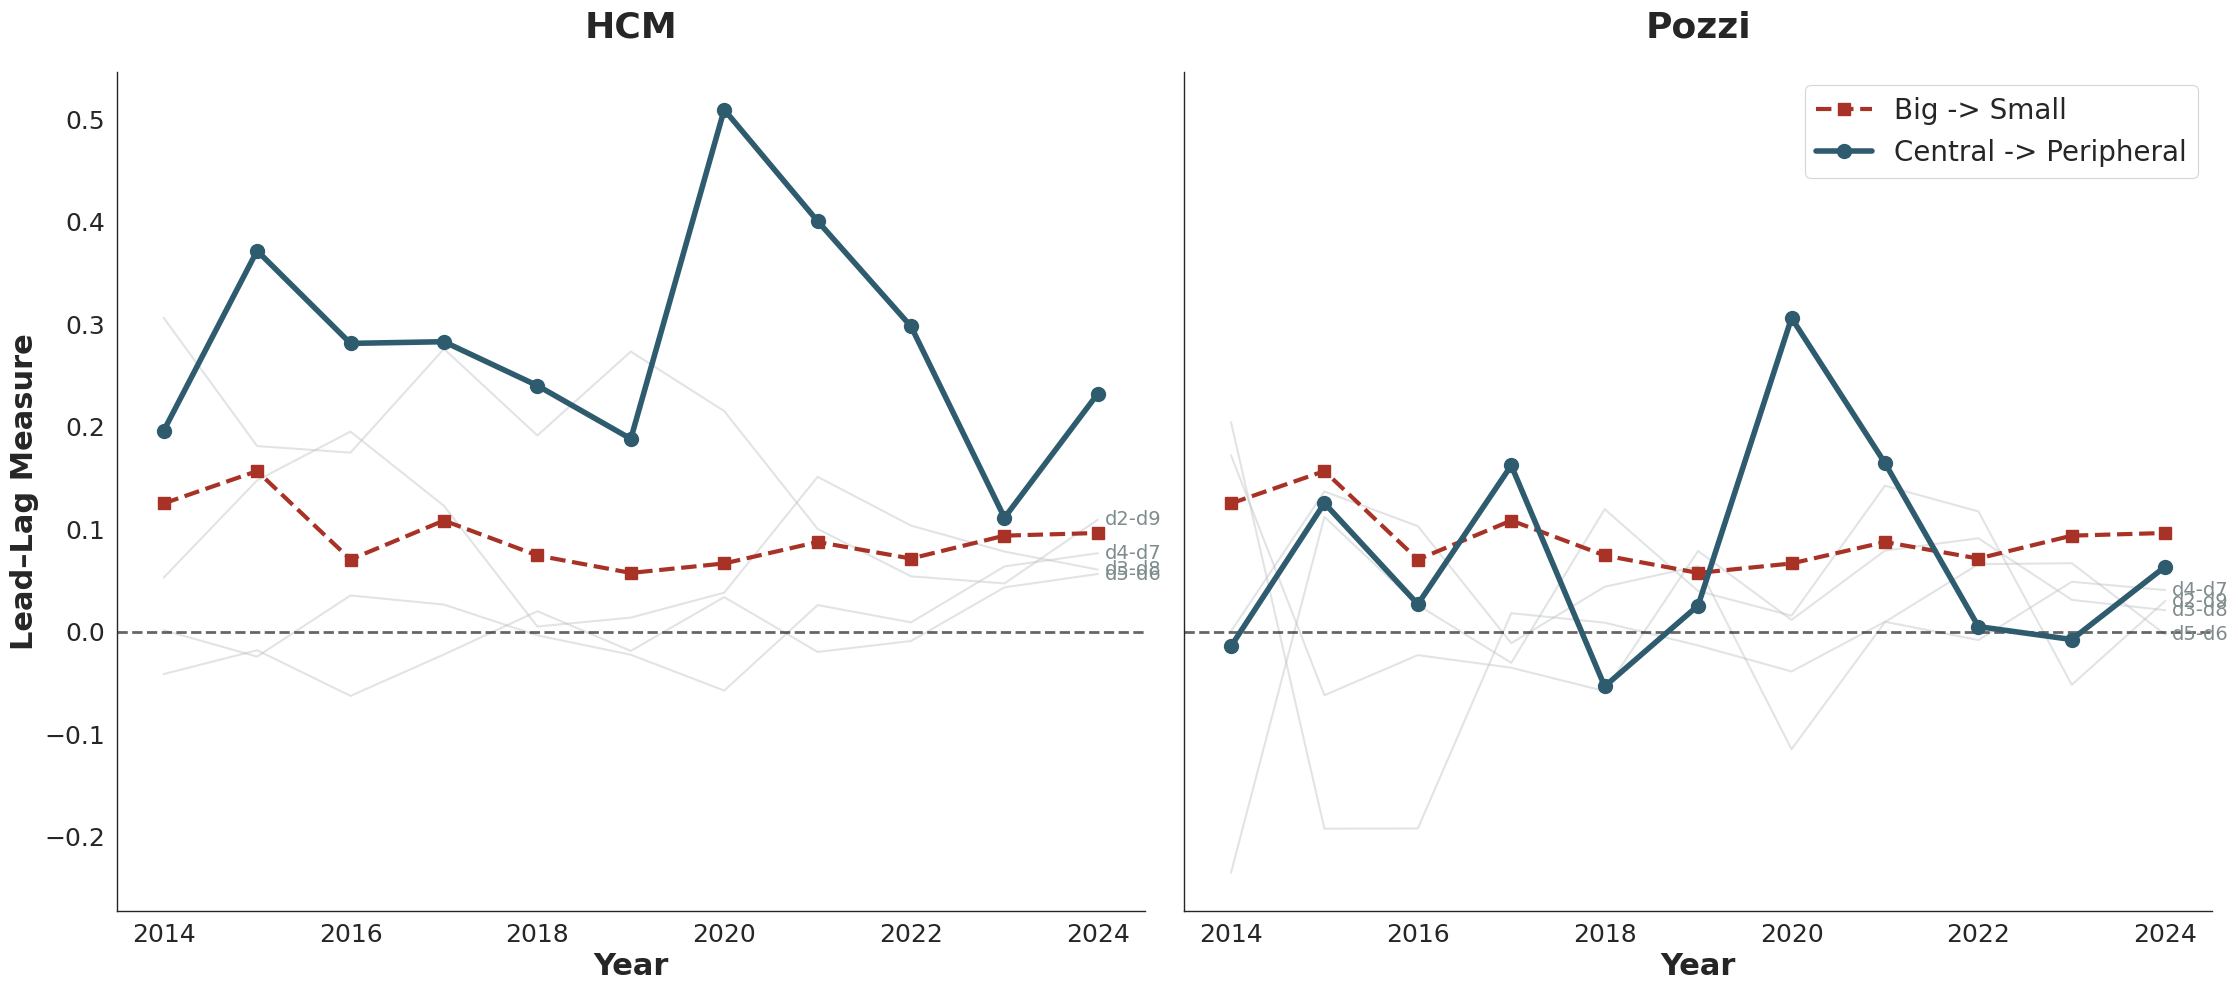

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Style Configuration ---
sns.set_theme(style="white", context="paper")

TITLE_SIZE = 26
LABEL_SIZE = 22
TICK_SIZE = 18
ANNOTATE_SIZE = 16
LINE_WIDTH_MAIN = 4.0
LINE_WIDTH_BACK = 1.5
MARKER_SIZE = 10

col_df = "cp1d"
metrics_list = ["HCM", "Pozzi"]

fig, axes = plt.subplots(1, 2, figsize=(24, 10), sharey=True)

# Nova Paleta (usada nos outros notebooks)
metric_colors = {"HCM": "#2E5C6E", "Pozzi": "#2E5C6E"}
mcap_color = "#A93226" # Vermelho destaque para Market Cap

for col, metric_name in enumerate(metrics_list):
    ax = axes[col]
    data_dict = all_metrics_data[metric_name]
    main_color = metric_colors[metric_name]
    
    # 1. Pares intermediários (cinza)
    back_pairs = [("d2_d9", "d2-d9"), ("d3_d8", "d3-d8"), ("d4_d7", "d4-d7"), ("d5_d6", "d5-d6")]
    for pair_key, pair_label in back_pairs:
        if pair_key in data_dict:
            df_pair = data_dict[pair_key].dropna(subset=[col_df])
            if not df_pair.empty:
                ax.plot(df_pair.index, df_pair[col_df], color="#BDC3C7", 
                        lw=LINE_WIDTH_BACK, alpha=0.45, zorder=1)
                
                last_year = df_pair.index[-1]
                last_val = df_pair[col_df].iloc[-1]
                ax.annotate(pair_label, xy=(last_year, last_val), xytext=(5, 0),
                            textcoords='offset points', fontsize=ANNOTATE_SIZE-2, 
                            color="#7F8C8D", va='center')
    
    # 2. Market Cap Baseline
    if not mcap_results.empty:
        df_mcap = mcap_results.dropna(subset=[col_df])
        if not df_mcap.empty:
            ax.plot(df_mcap.index, df_mcap[col_df], color=mcap_color,
                    lw=LINE_WIDTH_MAIN-1, ls="--", marker="s", markersize=MARKER_SIZE-2, zorder=4,
                    label="Big -> Small")
            
            last_year = df_mcap.index[-1]
            last_val = df_mcap[col_df].iloc[-1]
            # ax.annotate("Big -> Small", xy=(last_year, last_val), xytext=(8, -12),
            #             textcoords='offset points', fontsize=ANNOTATE_SIZE, 
            #             fontweight='bold', color=mcap_color, va='center')

    # 3. Par de destaque (d1_d10)
    if "d1_d10" in data_dict:
        df_main = data_dict["d1_d10"].dropna(subset=[col_df])
        if not df_main.empty:
            ax.plot(df_main.index, df_main[col_df], color=main_color,
                    lw=LINE_WIDTH_MAIN, marker="o", markersize=MARKER_SIZE, zorder=5,
                    label="Central -> Peripheral")
            
            last_year = df_main.index[-1]
            last_val = df_main[col_df].iloc[-1]
            # ax.annotate("Central -> Peripheral", xy=(last_year, last_val), xytext=(8, 12),
            #             textcoords='offset points', fontsize=ANNOTATE_SIZE, 
            #             fontweight='bold', color=main_color, va='center')
    
    # --- Formatação ---
    ax.set_title(f"{metric_name}", fontsize=TITLE_SIZE, fontweight="bold", pad=25)
    ax.set_xlabel("Year", fontsize=LABEL_SIZE, fontweight="bold")
    
    if col == 0:
        ax.set_ylabel("Lead–Lag Measure", fontsize=LABEL_SIZE, fontweight="bold")
    
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.axhline(0, color="black", lw=2, ls="--", alpha=0.6)
    
    ax.set_xlim(df_main.index.min() - 0.5, df_main.index.max() + 0.5)

sns.despine(fig=fig)
plt.tight_layout(rect=[0, 0, 0.94, 1])
plt.legend(fontsize=20)

os.makedirs("../../figures", exist_ok=True)
plt.savefig("../../figures/daily_leadlag_final_comparison.png", dpi=300, bbox_inches="tight")
plt.show()